In [ ]:
# Debugging Survey Data Read

import os
import pandas as pd
import numpy as np
import xlrd

print("-------------------- LOADING SURVEY DATA --------------------------------")


def parse_year(year_val):
    """Convert year string like '2022S', '2022A', '2022W' to numeric year."""
    # print("Year val is " + str(year_val) + " and its type is " + str(type(year_val)))
    if isinstance(year_val, str):
        if year_val.endswith("S"):
            return int(year_val[:-1]) - 0.5
        elif year_val.endswith(("A", "W")):
            return int(year_val[:-1])
        else:
            return int(year_val)  # just in case it's string but plain year
    return int(year_val)  # if it's already an int


# Set up paths
folder_path = "EU_dataset"
file_title = "Cleaned_Parlemeter_Data-LeftRight"
file_name = file_title + ".xlsx"
survey_file = os.path.join(folder_path, file_name)
sheets = pd.ExcelFile(survey_file, engine='openpyxl').sheet_names[1:]  # Skip 'RowHeaders'

survey_data = []

for sheet in sheets:
    # print(sheet)
    country = sheet.split("-")[0]  # Extract country code (e.g., "BE")
    df_sheet = pd.read_excel(survey_file, sheet_name=sheet, header=None, engine='openpyxl')

    # Years are in the first row
    years = df_sheet.iloc[0, :].tolist()
    # print(years)

    # Extract counts for positions 1-10 (skip % rows and DK/Refusal)
    counts_matrix = []
    for i in range(10):  # Positions 1-10
        row_index = 2 + 2 * i  # Count rows are at indices 1,3,5,...,19
        counts_matrix.append(df_sheet.iloc[row_index, :].tolist())

    # Process each year
    for j, year in enumerate(years):
        # print(f"Current year parsing: {year}")
        year_num = parse_year(year)  # use parsed numeric year
        # print(f" Count is: {float(counts_matrix[i][j])}")
        counts = [float(counts_matrix[i][j]) for i in range(10)]
        
        total_valid = sum(counts)
        distribution = [c / total_valid for c in counts]
        pooled_counts = counts[:4] + [counts[4] + counts[5]] + counts[6:]
        pooled_distribution = [c / total_valid for c in pooled_counts]

        survey_data.append({
            "country": country,
            "year": year_num,
            "counts": counts,
            "binned_distribution": distribution,
            "binned_distribution_5_6clubbed": pooled_distribution,
            "total_respondents": total_valid
        })
survey_df = pd.DataFrame(survey_data)
print("-------------------- SURVEY DATA LOADED --------------------------------")


In [ ]:
survey_df['counts'].iloc[0]

# AnalyseStepwiseFits -> Splitting logic test


In [ ]:

import csv
import numpy as np
import os
import pandas as pd

current_runs_title = "15.09.25"

steps_to_process = range(1,4)
js_fits_stepwise = []

full_preprocessed_data_folder_path = os.path.join("data", "preprocessed", "cluster", current_runs_title)


# Loading Data
for stepNo in steps_to_process:
    step_idx = stepNo - 1
    filename = f'JS_fits_Step{stepNo}.csv'
    file_path = os.path.join(full_preprocessed_data_folder_path, filename)
    df = pd.read_csv(file_path)
    js_fits_stepwise.append(df)


# Loading Active parameters for each model
active_params_stepwise = []
unique_param_combos_stepwise = []
param_summary_stepwise = []

for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()

    # Identify active parameters for this model
    active_params = []
    param_columns = ['epsM', 'epsSD', 'OpM', 'OpSD', 'MedM', 'MedSD', 
                    'MedInfF', 'Silence_Alpha', 'Silence_Tau', 
                    'Silence_Delta0', 'SilenceByBoundary']

    for param in param_columns:
        if df[param].nunique() > 1:
            active_params.append(param)
    active_params_stepwise.append(active_params)
    print(f"Model {stepNo}: Active params: {active_params}")
    
    # Identify unique parameter combinations (ignoring RandomSeed)
    unique_param_combos = df[active_params].drop_duplicates()
    print(f"Model {stepNo}: {len(unique_param_combos)} unique parameter combinations")
    unique_param_combos_stepwise.append(unique_param_combos)

In [ ]:
type(unique_param_combos_stepwise[0])

In [ ]:
# FUNCTIONS


def run_seed_split_overlap(df, active_params, n_splits=5, top_percentile=5):
    """
    Run random seed-based cross-validation overlap analysis
    """
    all_seeds = df['RandomSeed'].unique()
    overlap_results = []

    for split_idx in range(n_splits):
        # Random 50-50 seed split
        np.random.shuffle(all_seeds)
        split_point = len(all_seeds) // 2
        train_seeds = all_seeds[:split_point]
        test_seeds = all_seeds[split_point:]

        # Split data
        train_data = df[df['RandomSeed'].isin(train_seeds)]
        test_data = df[df['RandomSeed'].isin(test_seeds)]

        # Get successful parameter combinations
        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)

        # All possible parameter combinations
        all_param_combos = set([tuple(x) for x in df[active_params].drop_duplicates().values])

        # Calculate overlap
        overlap_metrics = calculate_overlap_metrics(train_success, test_success, all_param_combos)
        overlap_metrics['split_idx'] = split_idx
        overlap_metrics['split_type'] = 'seed'
        overlap_metrics['train_seeds'] = len(train_seeds)
        overlap_metrics['test_seeds'] = len(test_seeds)

        overlap_results.append(overlap_metrics)

    return overlap_results


def create_binary_success_metric(df, active_params, top_percentile=5):
    """
    Create binary success metric: 1 if in top 5% of fits, 0 otherwise
    """
    # Calculate fitness as minimum JSD across random seeds for each parameter combination
    fitness = df.groupby(active_params)['distance_final'].min().reset_index()
    fitness.columns = active_params + ['min_jsd']

    # Find threshold for top 5%
    threshold = fitness['min_jsd'].quantile(top_percentile / 100)

    # Mark successful parameter combinations
    fitness['success'] = (fitness['min_jsd'] <= threshold).astype(int)

    return fitness[active_params + ['success', 'min_jsd']]


def create_binary_success_metric_v2(df, active_params, top_percentile=5):
    """
    Improved version that tracks absolute counts
    """
    # Calculate fitness as minimum JSD across random seeds for each parameter combination
    fitness = df.groupby(active_params)['distance_final'].min().reset_index()
    fitness.columns = active_params + ['min_jsd']

    # Find threshold for top 5%
    threshold = fitness['min_jsd'].quantile(top_percentile / 100)

    # Mark successful parameter combinations
    fitness['success'] = (fitness['min_jsd'] <= threshold).astype(int)

    # Add absolute counts
    total_combos = len(fitness)
    good_combos = fitness['success'].sum()

    return fitness, total_combos, good_combos, threshold

def calculate_overlap_metrics(train_success, test_success, all_param_combos):
    """
    Calculate overlap metrics between training and test successful parameters
    """
    train_good = set([tuple(x) for x in train_success[train_success['success'] == 1][active_params].values])
    test_good = set([tuple(x) for x in test_success[test_success['success'] == 1][active_params].values])

    if len(all_param_combos) == 0:
        return {}

    overlap_metrics = {
        'total_param_space_size': len(all_param_combos),
        'train_good_size': len(train_good),
        'test_good_size': len(test_good),
        'overlap_size': len(train_good & test_good),
        'overlap_fraction_of_train': len(train_good & test_good) / len(train_good) if train_good else 0,
        'overlap_fraction_of_test': len(train_good & test_good) / len(test_good) if test_good else 0,
        'overlap_fraction_of_total': len(train_good & test_good) / len(all_param_combos),
        'train_success_rate': len(train_good) / len(all_param_combos),
        'test_success_rate': len(test_good) / len(all_param_combos)
    }

    return overlap_metrics
    
def calculate_overlap_metrics_v2(train_success, test_success, all_param_combos):
    """
    Improved overlap metrics with absolute numbers
    """
    train_good = set([tuple(x) for x in train_success[train_success['success'] == 1][active_params].values])
    test_good = set([tuple(x) for x in test_success[test_success['success'] == 1][active_params].values])

    # print(train_good)
    if len(all_param_combos) == 0:
        return {}

    total_space_size = len(all_param_combos)
    overlap_size = len(train_good & test_good)

    overlap_metrics = {
        'total_param_space_size': total_space_size,
        'train_good_size': len(train_good),
        'test_good_size': len(test_good),
        'overlap_size': overlap_size,
        'overlap_fraction_of_train': overlap_size / len(train_good) if train_good else 0,
        'overlap_fraction_of_test': overlap_size / len(test_good) if test_good else 0,
        'overlap_fraction_of_total': overlap_size / total_space_size,
        'train_success_rate': len(train_good) / total_space_size,
        'test_success_rate': len(test_good) / total_space_size,
        'train_good_abs': len(train_good),
        'test_good_abs': len(test_good),
        'overlap_abs': overlap_size
    }

    return overlap_metrics

def run_country_split_overlap_v2(df, active_params, n_splits=5, top_percentile=5):
    """
    Improved version with better reporting
    """
    countries = df['country'].unique()
    overlap_results = []

    for split_idx in range(n_splits):
        # Random 50-50 country split
        np.random.shuffle(countries)
        split_point = len(countries) // 2
        train_countries = countries[:split_point]
        test_countries = countries[split_point:]

        # Split data
        train_data = df[df['country'].isin(train_countries)]
        test_data = df[df['country'].isin(test_countries)]

        # Get successful parameter combinations
        train_success, train_total, train_good, train_threshold = create_binary_success_metric_v2(train_data, active_params, top_percentile)
        test_success, test_total, test_good, test_threshold = create_binary_success_metric_v2(test_data, active_params, top_percentile)

        # All possible parameter combinations
        all_param_combos = set([tuple(x) for x in df[active_params].drop_duplicates().values])

        # Calculate overlap
        overlap_metrics = calculate_overlap_metrics_v2(train_success, test_success, all_param_combos)
        overlap_metrics['split_idx'] = split_idx
        overlap_metrics['split_type'] = 'country'
        overlap_metrics['train_countries'] = len(train_countries)
        overlap_metrics['test_countries'] = len(test_countries)
        overlap_metrics['train_threshold'] = train_threshold
        overlap_metrics['test_threshold'] = test_threshold

        overlap_results.append(overlap_metrics)

    return overlap_results

In [ ]:
overlap_results_stepwise = []

for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()
    active_params = active_params_stepwise[step_idx]

    print(f"\n{'='*60}")
    print(f"MODEL {stepNo} OVERLAP ANALYSIS")
    print(f"{'='*60}")

    model_results = {
        'stepNo': stepNo,
        'country_splits': [],
        'seed_splits': []
    }

    # Run country-based splits
    print("Running country splits...")
    country_results = run_country_split_overlap_v2(df, active_params, n_splits=5, top_percentile=5)
    model_results['country_splits'] = country_results

    # Run seed-based splits (only if multiple seeds exist)
    if df['RandomSeed'].nunique() > 1:
        print("Running seed splits...")
        seed_results = run_seed_split_overlap(df, active_params, n_splits=5, top_percentile=5)
        model_results['seed_splits'] = seed_results
    else:
        print("Skipping seed splits (only one RandomSeed)")
        model_results['seed_splits'] = []

    overlap_results_stepwise.append(model_results)

    # Print summary for this model
    print(f"\nModel {stepNo} Summary:")
    if country_results:
        country_overlaps = [r['overlap_fraction_of_train'] for r in country_results]
        print(f"  Country splits - Mean overlap: {np.mean(country_overlaps):.3f} ± {np.std(country_overlaps):.3f}")

    if model_results['seed_splits']:
        seed_overlaps = [r['overlap_fraction_of_train'] for r in model_results['seed_splits']]
        print(f"  Seed splits - Mean overlap: {np.mean(seed_overlaps):.3f} ± {np.std(seed_overlaps):.3f}")


In [ ]:
import matplotlib.pyplot as plt

def test_and_visualize_country_splits(df, active_params, unique_combos_df, 
                                      n_splits=5, top_percentile=5, random_seed=None):
    """
    Replicates run_country_split_overlap_v2 logic, but prints and visualizes each split.
    """
    if len(active_params) > 2:
        print(f"Active dimensions = {len(active_params)} -> cannot plot, skipping.")
        return

    countries = df['country'].unique()
    if random_seed is not None:
        np.random.seed(random_seed)   # for reproducibility of the test

    for split_idx in range(n_splits):
        # ---- identical splitting as in run_country_split_overlap_v2 ----
        np.random.shuffle(countries)
        split_point = len(countries) // 2
        train_countries = countries[:split_point]
        test_countries = countries[split_point:]

        train_data = df[df['country'].isin(train_countries)]
        test_data = df[df['country'].isin(test_countries)]

        # Use your original create_binary_success_metric (not v2) to get the sets
        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)

        train_good = set(tuple(x) for x in train_success[train_success['success'] == 1][active_params].values)
        test_good  = set(tuple(x) for x in test_success[test_success['success'] == 1][active_params].values)
        overlap = train_good & test_good

        # ---- print diagnostic info ----
        print(f"\nCountry split {split_idx+1}:")
        print(f"  Train countries: {train_countries}")
        print(f"  Test countries : {test_countries}")
        print(f"  |train_good| = {len(train_good)}, |test_good| = {len(test_good)}, |overlap| = {len(overlap)}")
        if len(train_good) > 0:
            print(f"  overlap fraction (of train) = {len(overlap)/len(train_good):.3f}")
        else:
            print("  overlap fraction = 0 (no train_good)")

        # ---- visualisation ----
        plot_param_space_with_sets(unique_combos_df, train_good, test_good, active_params,
                                   title_prefix=f"Country split {split_idx+1}")


def test_and_visualize_seed_splits(df, active_params, unique_combos_df,
                                   n_splits=5, top_percentile=5, random_seed=None):
    """
    Replicates run_seed_split_overlap logic, but prints and visualizes each split.
    """
    if len(active_params) > 2:
        print(f"Active dimensions = {len(active_params)} -> cannot plot, skipping.")
        return

    if df['RandomSeed'].nunique() < 2:
        print("Not enough RandomSeeds for seed splits.")
        return

    all_seeds = df['RandomSeed'].unique()
    if random_seed is not None:
        np.random.seed(random_seed)

    for split_idx in range(n_splits):
        np.random.shuffle(all_seeds)
        split_point = len(all_seeds) // 2
        train_seeds = all_seeds[:split_point]
        test_seeds = all_seeds[split_point:]

        train_data = df[df['RandomSeed'].isin(train_seeds)]
        test_data = df[df['RandomSeed'].isin(test_seeds)]

        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)

        train_good = set(tuple(x) for x in train_success[train_success['success'] == 1][active_params].values)
        test_good  = set(tuple(x) for x in test_success[test_success['success'] == 1][active_params].values)
        overlap = train_good & test_good

        print(f"\nSeed split {split_idx+1}:")
        print(f"  Train seeds: {train_seeds}")
        print(f"  Test seeds : {test_seeds}")
        print(f"  |train_good| = {len(train_good)}, |test_good| = {len(test_good)}, |overlap| = {len(overlap)}")
        if len(train_good) > 0:
            print(f"  overlap fraction (of train) = {len(overlap)/len(train_good):.3f}")

        plot_param_space_with_sets(unique_combos_df, train_good, test_good, active_params,
                                   title_prefix=f"Seed split {split_idx+1}")


def plot_param_space_with_sets(unique_combos_df, train_good_set, test_good_set,
                               active_params, title_prefix=""):
    """Same plotting function as before – 1D or 2D."""
    n_dims = len(active_params)
    if n_dims == 1:
        param = active_params[0]
        x_vals = sorted(unique_combos_df[param].unique())
        fig, ax = plt.subplots(figsize=(10, 2))
        for x in x_vals:
            ax.scatter(x, 0, c='blue', marker='o', s=80, alpha=0.6)
        for (x,) in train_good_set:
            if (x,) in test_good_set:
                ax.scatter(x, 0, c='red', marker='x', s=150, linewidth=3)
            else:
                ax.scatter(x, 0, c='green', marker='s', s=100)
        for (x,) in test_good_set:
            if (x,) not in train_good_set:
                ax.scatter(x, 0, c='orange', marker='*', s=150)
        ax.set_yticks([])
        ax.set_xlabel(param)
        ax.set_title(f"{title_prefix}\n1D parameter space")
        ax.grid(axis='x', linestyle=':', alpha=0.5)
    elif n_dims == 2:
        px, py = active_params[0], active_params[1]
        x_vals = sorted(unique_combos_df[px].unique())
        y_vals = sorted(unique_combos_df[py].unique())
        fig, ax = plt.subplots(figsize=(8, 6))
        for _, row in unique_combos_df.iterrows():
            ax.scatter(row[px], row[py], c='blue', marker='o', s=60, alpha=0.4)
        for tup in (train_good_set & test_good_set):
            ax.scatter(tup[0], tup[1], c='red', marker='x', s=200, linewidth=3)
        for tup in (train_good_set - test_good_set):
            ax.scatter(tup[0], tup[1], c='green', marker='s', s=120)
        for tup in (test_good_set - train_good_set):
            ax.scatter(tup[0], tup[1], c='orange', marker='*', s=180)
        ax.set_xticks(x_vals)
        ax.set_yticks(y_vals)
        ax.set_xlabel(px)
        ax.set_ylabel(py)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_title(f"{title_prefix}\n2D parameter space\n"
                     f"◉ all combos  ■ train only  ★ test only  ✗ overlap")
    else:
        print(f"Cannot plot: {n_dims} dimensions.")
        return
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# Run the tests for each model (using your already loaded data)
# -------------------------------------------------------------------
for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()
    active_params = active_params_stepwise[step_idx]
    unique_combos_df = unique_param_combos_stepwise[step_idx]   # from your earlier computation

    print(f"\n{'='*70}")
    print(f"TESTING MODEL {stepNo} – Active params: {active_params}")
    print(f"Total unique parameter combinations: {len(unique_combos_df)}")

    # Test country splits (set a fixed seed so you can compare runs)
    test_and_visualize_country_splits(df, active_params, unique_combos_df,
                                      n_splits=5, top_percentile=5, random_seed=42)

    # Test seed splits
    test_and_visualize_seed_splits(df, active_params, unique_combos_df,
                                   n_splits=5, top_percentile=5, random_seed=42)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_param_space(unique_param_combos, train_good, figsize=(8, 6)):
    """
    Visualize a parameter space grid (1D or 2D) and mark the 'good' combinations.

    Parameters
    ----------
    unique_param_combos : pd.DataFrame
        Each column is a dimension, each row is one unique combination.
        For 2D, exactly two columns; for 1D, exactly one column.
    train_good : set of tuples
        Each tuple contains values in the same order as the DataFrame columns.
        Example: for 2D with columns ['param1','param2'], train_good = {(0.1, 'A'), (0.2, 'B')}
    figsize : tuple, optional
        Size of the matplotlib figure.
    """
    dims = unique_param_combos.shape[1]
    if dims == 1:
        # ---------- 1D case ----------
        col = unique_param_combos.columns[0]
        x_vals = unique_param_combos[col].values
        # Create a set of good values for fast lookup (since tuples have one element)
        good_vals = {t[0] for t in train_good}

        fig, ax = plt.subplots(figsize=figsize)
        # Plot all points as small blue circles
        ax.scatter(x_vals, np.zeros_like(x_vals), c='blue', marker='o', s=50, label='all combos')
        # Mark good ones with red 'x'
        good_x = [v for v in x_vals if v in good_vals]
        ax.scatter(good_x, np.zeros_like(good_x), c='red', marker='x', s=100, label='train_good')
        # Add a grid and remove y-axis spines for a clean 1D look
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        ax.set_xlabel(col)
        ax.set_title('1D Parameter Space')
        ax.legend()
        plt.tight_layout()
        plt.show()

    elif dims == 2:
        # ---------- 2D case ----------
        col0, col1 = unique_param_combos.columns[0], unique_param_combos.columns[1]
        # Get all unique values along each dimension (sorted for visual order)
        x_vals = sorted(unique_param_combos[col0].unique())
        y_vals = sorted(unique_param_combos[col1].unique())
        # Build a set for fast membership test
        good_set = set(train_good)

        fig, ax = plt.subplots(figsize=figsize)
        # Plot every combination as a small gray dot
        for _, row in unique_param_combos.iterrows():
            x = row[col0]
            y = row[col1]
            ax.plot(x, y, 'o', color='lightgray', markersize=6, markeredgecolor='none')
        # Overlay 'good' combinations with red 'x'
        for (x, y) in good_set:
            ax.plot(x, y, 'x', color='red', markersize=10, markeredgewidth=2)

        # Adjust ticks to show the actual parameter values
        ax.set_xticks(x_vals)
        ax.set_yticks(y_vals)
        ax.set_xlabel(col0)
        ax.set_ylabel(col1)
        ax.set_title('2D Parameter Space (gray o = all combos, red x = train_good)')
        # Add a light grid to emphasise the discrete cells
        ax.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError(f"This visualizer only supports 1 or 2 dimensions. Found {dims} dimensions.")

# ========== Example usage ==========
if __name__ == "__main__":
    # ----- 2D example -----
    param1 = [0.1, 0.1, 0.2, 0.2]
    param2 = ['A', 'B', 'A', 'B']
    df_2d = pd.DataFrame({'learning_rate': param1, 'activation': param2})
    good_2d = {(0.1, 'A'), (0.2, 'B')}   # mark these two points
    plot_param_space(df_2d, good_2d)

    # ----- 1D example -----
    df_1d = pd.DataFrame({'dropout': [0.0, 0.2, 0.5, 0.7]})
    good_1d = {(0.2,), (0.7,)}          # note the comma for 1‑tuple
    plot_param_space(df_1d, good_1d)

# Visualize Distributions (earlier 2SpaceParameterSearch.ipynb)

Running 2SpaceParamSearch_Cluster.py
The following steps will be processed: 

Step 1 

Step 2 

Step 3 


Running percentile Analysis...
Starting complete percentile analysis
Models: [1, 2, 3, 4, 5, 6]
Percentiles: [5, 0.5, 0.05]
Saving top percentile data for models 1-6
Percentiles to save: [5, 0.5, 0.05]%

############################################################
PROCESSING MODEL 1
############################################################
  Loaded 1,047,900 comparisons for Model 1
  ✓ Saved top 5% (52,395 rows) to model_1_top_5pct.parquet
  ✓ Saved top 0.5% (5,240 rows) to model_1_top_0.5pct.parquet
  ✓ Saved top 0.05% (524 rows) to model_1_top_0.05pct.parquet

############################################################
PROCESSING MODEL 2
############################################################
  Loaded 1,047,900 comparisons for Model 2
  ✓ Saved top 5% (52,395 rows) to model_2_top_5pct.parquet
  ✓ Saved top 0.5% (5,240 rows) to model_2_top_0.5pct.parquet
  ✓ Saved top 0.0

FileNotFoundError: [Errno 2] No such file or directory: 'analysis\\plots\\cluster\\15.09.25\\Step1-May.26_Parlemeter_LR\\JSD_Top_Fits\\JSD_Top_Percentiles_Model_BoxplotAndViolin.png'

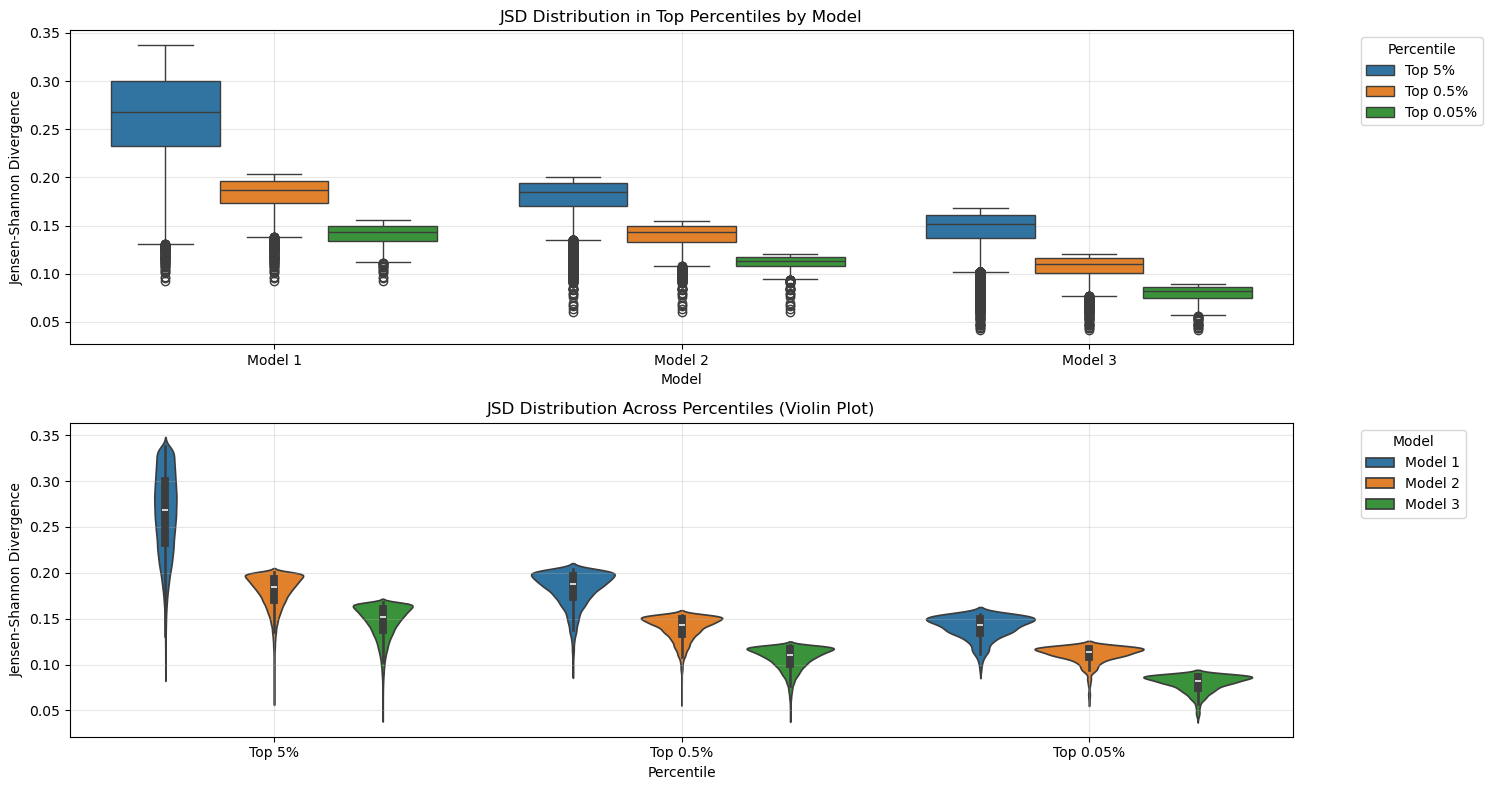

In [26]:
import csv
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


save_best_fit_data = True
load_best_fit_data = True

run_preliminary_sensitivity_analysis = True


current_runs_title = "15.09.25"
current_analysis_title = "Step1-May.26_Parlemeter_LR"

steps_to_process = range(1,4)
js_fits_stepwise = []

print("Running 2SpaceParamSearch_Cluster.py")
print(f"The following steps will be processed: \n")
for i in (steps_to_process):
    print(f"Step {i} \n")

full_preprocessed_data_folder_path = os.path.join("data", "preprocessed", "cluster", current_runs_title)
plots_folder_path = os.path.join("analysis", "plots", "cluster", current_runs_title, current_analysis_title)


for stepNo in steps_to_process:
    step_idx = stepNo - 1
    filename = f'JS_fits_Step{stepNo}.csv'

    file_path = os.path.join(full_preprocessed_data_folder_path, filename)
    df = pd.read_csv(file_path)
    js_fits_stepwise.append(df)



def save_top_percentile_data(js_fits_stepwise, percentiles_to_save=[5, 2, 1, 0.5, 0.05], base_save_path=os.path.join('data','preprocessed', 'cluster','top_percentiles')):
    """
    Save top percentile data for each model to separate files
    """
    # Create save directory
    os.makedirs(base_save_path, exist_ok=True)

    print(f"Saving top percentile data for models 1-6")
    print(f"Percentiles to save: {percentiles_to_save}%")

    all_models_results = {}

    for model_idx in (np.array(steps_to_process) - 1):  # Models 0-5 representing models 1-6
        model_number = model_idx + 1
        print(f"\n{'#'*60}")
        print(f"PROCESSING MODEL {model_number}")
        print(f"{'#'*60}")

        # Load the dataframe for this model
        df = js_fits_stepwise[model_idx].copy()
        print(f"  Loaded {len(df):,} comparisons for Model {model_number}")

        model_results = {}

        for percentile in percentiles_to_save:
            # Calculate threshold for this percentile
            threshold = df['distance_final'].quantile(percentile / 100)

            # Get top percentile data
            top_data = df[df['distance_final'] <= threshold].copy()

            # Add percentile information
            top_data['percentile_threshold'] = percentile
            top_data['is_top_percentile'] = True

            # Save to file
            filename = f"model_{model_number}_top_{percentile}pct.parquet"
            filepath = os.path.join(base_save_path, filename)

            try:
                top_data.to_parquet(filepath)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {filename}")
            except Exception as e:
                # Fallback to CSV if parquet fails
                csv_filepath = filepath.replace('.parquet', '.csv')
                top_data.to_csv(csv_filepath, index=False)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {csv_filepath} (CSV)")

            model_results[percentile] = {
                'data': top_data,
                'threshold': threshold,
                'count': len(top_data)
            }

        all_models_results[model_number] = model_results

    # Print summary
    print(f"\n{'#'*60}")
    print("SUMMARY")
    print(f"{'#'*60}")

    for model_number in steps_to_process:
        print(f"\nModel {model_number}:")
        for percentile in percentiles_to_save:
            count = all_models_results[model_number][percentile]['count']
            threshold = all_models_results[model_number][percentile]['threshold']
            print(f"  Top {percentile:5.2f}%: {count:>8,} rows (JSD ≤ {threshold:.4f})")

    return all_models_results

def load_top_percentile_data(model_numbers, percentiles, base_save_path=os.path.join('data','preprocessed', 'cluster','top_percentiles')):
    """
    Load pre-saved top percentile data
    """
    loaded_data = {}
    # for m in model_numbers:
    #     print(f"THIS MODEL IS {m}")
    for model_number in model_numbers:
        model_data = {}

        for percentile in percentiles:
            # Try parquet first, then CSV
            # print(f"Loading model_{model_number}_top_{percentile}pct.parquet")
            parquet_path = os.path.join(base_save_path, f"model_{model_number}_top_{percentile}pct.parquet")
            csv_path = os.path.join(base_save_path, f"model_{model_number}_top_{percentile}pct.csv")
            # print("LISTING EVERYTHINGG:")
            # for f in os.listdir(base_save_path):
                # print(f)
                # print(parquet_path)
                
            if os.path.exists(parquet_path):
                data = pd.read_parquet(parquet_path)
            elif os.path.exists(csv_path):
                data = pd.read_csv(csv_path)
            else:
                print(f"Warning: No data found for Model {model_number}, {percentile}%")
                continue

            model_data[percentile] = data

        if model_data:  # Only add if we found data
            loaded_data[model_number] = model_data

    return loaded_data

def create_percentile_boxplots(loaded_data, percentiles, model_numbers=None, figsize=(15, 8)):
    """
    Create boxplots for multiple percentiles and models
    """
    if model_numbers is None:
        model_numbers = list(loaded_data.keys())

    # Prepare data for plotting
    plot_data = []

    for model_number in model_numbers:
        if model_number not in loaded_data:
            continue

        for percentile in percentiles:
            if percentile not in loaded_data[model_number]:
                continue

            data = loaded_data[model_number][percentile]

            for jsd_value in data['distance_final']:
                plot_data.append({
                    'model': f'Model {model_number}',
                    'percentile': f'Top {percentile}%',
                    'jsd': jsd_value,
                    'percentile_value': percentile,
                    'model_number': model_number
                })

    plot_df = pd.DataFrame(plot_data)

    if plot_df.empty:
        print("No data to plot! Check if files were created correctly.")
        return None, None

    # Create the boxplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)

    # Plot 1: Boxplot by model and percentile
    sns.boxplot(data=plot_df, x='model', y='jsd', hue='percentile', ax=ax1)
    ax1.set_title('JSD Distribution in Top Percentiles by Model')
    ax1.set_ylabel('Jensen-Shannon Divergence')
    ax1.set_xlabel('Model')
    ax1.legend(title='Percentile', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Violin plot for better distribution visualization
    sns.violinplot(data=plot_df, x='percentile', y='jsd', hue='model', ax=ax2, split=False)
    ax2.set_title('JSD Distribution Across Percentiles (Violin Plot)')
    ax2.set_ylabel('Jensen-Shannon Divergence')
    ax2.set_xlabel('Percentile')
    ax2.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    folder_path = os.path.join(plots_folder_path, "JSD_Top_Fits")
    filename = "JSD_Top_Percentiles_Model_BoxplotAndViolin"
    plt.savefig(os.path.join(folder_path, filename + ".png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(folder_path, filename + ".svg"), bbox_inches='tight')

    # Print statistics
    print(f"\n{'#'*60}")
    print("BOXPLOT STATISTICS")
    print(f"{'#'*60}")

    stats = plot_df.groupby(['model', 'percentile'])['jsd'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
    print(stats)

    return fig, plot_df

def create_comparison_plots(loaded_data, percentiles, focus_model=None, figsize=(16, 10)):
    """
    Create detailed comparison plots focusing on specific aspects
    """
    # Prepare data
    plot_data = []

    for model_number in loaded_data.keys():
        for percentile in percentiles:
            if percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]
                for jsd_value in data['distance_final']:
                    plot_data.append({
                        'model': f'Model {model_number}',
                        'percentile': percentile,
                        'jsd': jsd_value
                    })

    plot_df = pd.DataFrame(plot_data)

    if plot_df.empty:
        print("No data available for comparison plots")
        return None, None

    # Create comprehensive figure
    fig = plt.figure(figsize=figsize)

    # 1. Main boxplot
    ax1 = plt.subplot(2, 2, 1)
    sns.boxplot(data=plot_df, x='percentile', y='jsd', hue='model', ax=ax1)
    ax1.set_title('JSD Distribution by Percentile and Model')
    ax1.set_ylabel('JSD')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 2. Violin plot
    ax2 = plt.subplot(2, 2, 2)
    sns.violinplot(data=plot_df, x='percentile', y='jsd', hue='model', ax=ax2, split=False)
    ax2.set_title('JSD Distribution (Violin Plot)')
    ax2.set_ylabel('JSD')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 3. Point plot with confidence intervals
    ax3 = plt.subplot(2, 2, 3)
    sns.pointplot(data=plot_df, x='percentile', y='jsd', hue='model', 
                  ax=ax3, ci=95, capsize=0.1)
    ax3.set_title('Mean JSD with 95% Confidence Intervals')
    ax3.set_ylabel('Mean JSD')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 4. Cumulative distribution
    ax4 = plt.subplot(2, 2, 4)
    for model in plot_df['model'].unique():
        model_data = plot_df[plot_df['model'] == model]
        for percentile in sorted(plot_df['percentile'].unique()):
            percentile_data = model_data[model_data['percentile'] == percentile]['jsd']
            if len(percentile_data) > 0:
                ax4.hist(percentile_data, bins=50, alpha=0.5, 
                        label=f'{model} - Top {percentile}%', density=True, histtype='step', linewidth=2)

    ax4.set_title('JSD Distribution Density by Model and Percentile')
    ax4.set_xlabel('JSD')
    ax4.set_ylabel('Density')
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    folder_path = os.path.join(plots_folder_path, "JSD_Top_Fits")
    filename = "JSD_Distribution_by_Percentile_and_Model"
    plt.savefig(os.path.join(folder_path, filename + '.png'), bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(folder_path, filename + '.svg'), bbox_inches='tight')

    return fig, plot_df

def create_single_percentile_comparison(loaded_data, percentile, figsize=(12, 6)):
    """
    Create focused comparison for a single percentile across all models
    """
    plot_data = []
    this_model_number = 0

    for model_number in loaded_data.keys():
        this_model_number = model_number
        if percentile in loaded_data[model_number]:
            data = loaded_data[model_number][percentile]
            for jsd_value in data['distance_final']:
                plot_data.append({
                    'model': f'Model {model_number}',
                    'jsd': jsd_value
                })

    if not plot_data:
        print(f"No data available for percentile {percentile}%")
        return None, None

    plot_df = pd.DataFrame(plot_data)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Boxplot
    sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1)
    ax1.set_title(f'JSD Distribution - Top {percentile}% Best Fits')
    ax1.set_ylabel('Jensen-Shannon Divergence')
    ax1.grid(True, alpha=0.3)

    # Violin plot
    sns.violinplot(data=plot_df, x='model', y='jsd', ax=ax2)
    ax2.set_title(f'JSD Distribution - Top {percentile}% Best Fits')
    ax2.set_ylabel('Jensen-Shannon Divergence')
    ax2.grid(True, alpha=0.3)



    plt.tight_layout()
    folder_path = os.path.join(plots_folder_path, "JSD_Top_Fits")
    filename = f"JSD Distribution by Model for Top {percentile} percentile of top fits of model  {this_model_number}"
    plt.savefig(os.path.join(folder_path, filename + '.png'), bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(folder_path, filename + '.svg'), bbox_inches='tight')




    # Print comparison statistics
    stats = plot_df.groupby('model')['jsd'].agg(['count', 'mean', 'std', 'min', 'median', 'max']).round(4)
    print(f"\nComparison for Top {percentile}%:")
    print(stats)

    return fig, plot_df

# Main execution pipeline - FIXED VERSION
def run_complete_percentile_analysis(js_fits_stepwise, percentiles_to_save=[5, 2, 1, 0.5, 0.05], models_to_analyze=None):
    """
    Complete pipeline: save data and create visualizations
    """
    if models_to_analyze is None:
        models_to_analyze = list(steps_to_process)

    print(f"Starting complete percentile analysis")
    print(f"Models: {models_to_analyze}")
    print(f"Percentiles: {percentiles_to_save}")

    # Step 1: Save top percentile data
    saved_data = save_top_percentile_data(js_fits_stepwise, percentiles_to_save)

    # Step 2: Load the data back (to demonstrate the file-based approach)
    loaded_data = load_top_percentile_data(models_to_analyze, percentiles_to_save)

    # Step 3: Create comprehensive visualizations
    print(f"\n{'#'*60}")
    print("CREATING VISUALIZATIONS")
    print(f"{'#'*60}")

    results = {
        'saved_data': saved_data,
        'loaded_data': loaded_data,
        'figures': {},
        'plot_data': {}
    }

    # Main boxplots
    fig1, plot_df1 = create_percentile_boxplots(loaded_data, percentiles_to_save, models_to_analyze)
    if fig1 is not None:
        results['figures']['main_boxplots'] = fig1
        results['plot_data']['main'] = plot_df1

    # Detailed comparison
    fig2, plot_df2 = create_comparison_plots(loaded_data, percentiles_to_save)
    if fig2 is not None:
        results['figures']['comparison_plots'] = fig2
        results['plot_data']['comparison'] = plot_df2

    # Individual percentile comparisons
    individual_figs = {}
    for percentile in percentiles_to_save:
        fig, df = create_single_percentile_comparison(loaded_data, percentile)
        if fig is not None:
            individual_figs[percentile] = fig

    results['figures']['individual_percentiles'] = individual_figs

    return results

print("\nRunning percentile Analysis...")
results = run_complete_percentile_analysis(
    js_fits_stepwise, 
    percentiles_to_save=[5, 0.5, 0.05],
    models_to_analyze=[1, 2, 3, 4, 5, 6]
)
    


SAVING IMPROVED TOP PERCENTILE DATA...
Saving IMPROVED top percentile data for models 1-6
Percentiles to save: [5, 2, 1, 0.5, 0.05]%
Filter: Only simulations where distance_final < distance_initial

############################################################
PROCESSING MODEL 1
############################################################
  Loaded 1,047,900 total comparisons
  Found 20,589 improved simulations (2.0%)
  ✓ Saved top 5% (1,030 rows) to improved_model_1_top_5pct.parquet
  ✓ Saved top 2% (412 rows) to improved_model_1_top_2pct.parquet
  ✓ Saved top 1% (206 rows) to improved_model_1_top_1pct.parquet
  ✓ Saved top 0.5% (103 rows) to improved_model_1_top_0.5pct.parquet
  ✓ Saved top 0.05% (11 rows) to improved_model_1_top_0.05pct.parquet

############################################################
PROCESSING MODEL 2
############################################################
  Loaded 1,047,900 total comparisons
  Found 172,618 improved simulations (16.5%)
  ✓ Saved top 5% (8,

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8340\1421687974.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1, palette='viridis')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8340\1421687974.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='model', y='improvement', ax=ax2, palette='plasma')


FileNotFoundError: [Errno 2] No such file or directory: 'analysis\\plots\\cluster\\15.09.25\\Step1-May.26_Parlemeter_LR\\JSD_Top_Improved_Fits\\JSD Improvement Distribution by Model for Top 5 percentile by fit.png'

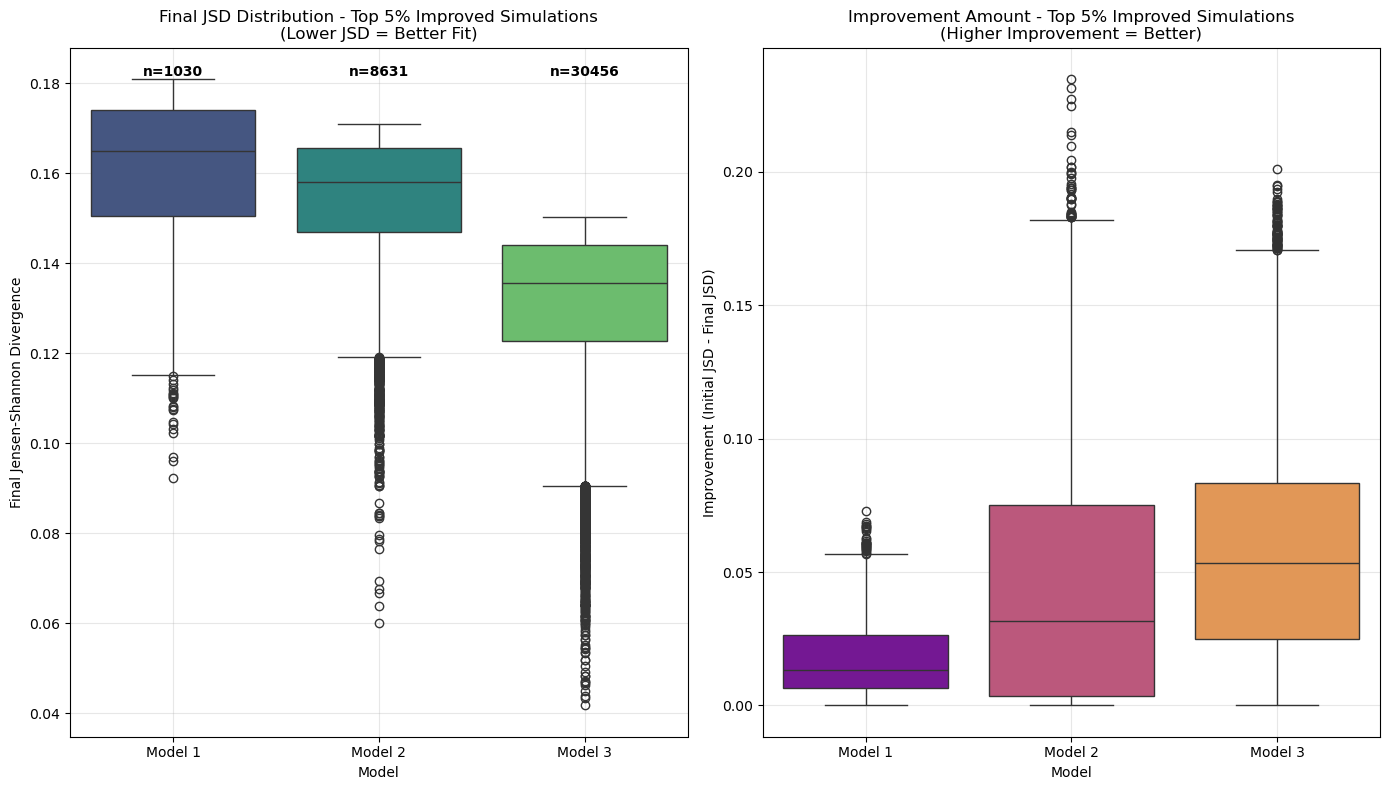

In [28]:

def save_improved_top_percentile_data(js_fits_stepwise, percentiles_to_save=[5, 2, 1, 0.5, 0.05], base_save_path=os.path.join('data','preprocessed', 'cluster','improved_top_percentiles')):
    """
    Save top percentile data for each model, filtering only improved simulations (distance_final < distance_initial)
    """
    # Create save directory
    os.makedirs(base_save_path, exist_ok=True)

    print(f"Saving IMPROVED top percentile data for models 1-6")
    print(f"Percentiles to save: {percentiles_to_save}%")
    print(f"Filter: Only simulations where distance_final < distance_initial")

    all_models_results = {}

    for model_number in steps_to_process:  # Models 0-5 representing models 1-6
        model_idx = model_number - 1
        print(f"\n{'#'*60}")
        print(f"PROCESSING MODEL {model_number}")
        print(f"{'#'*60}")

        # Load the dataframe for this model
        df = js_fits_stepwise[model_idx].copy()
        print(f"  Loaded {len(df):,} total comparisons")

        # Filter for improved simulations only
        improved_df = df[df['distance_final'] < df['distance_initial']].copy()
        print(f"  Found {len(improved_df):,} improved simulations ({len(improved_df)/len(df)*100:.1f}%)")

        if len(improved_df) == 0:
            print(f"  ⚠️  No improved simulations found for Model {model_number}")
            continue

        model_results = {}

        for percentile in percentiles_to_save:
            # Calculate threshold for this percentile (within improved simulations)
            threshold = improved_df['distance_final'].quantile(percentile / 100)

            # Get top percentile data from improved simulations
            top_data = improved_df[improved_df['distance_final'] <= threshold].copy()

            # Add metadata
            top_data['percentile_threshold'] = percentile
            top_data['is_top_percentile'] = True
            top_data['improvement_amount'] = top_data['distance_initial'] - top_data['distance_final']

            # Save to file
            filename = f"improved_model_{model_number}_top_{percentile}pct.parquet"
            filepath = os.path.join(base_save_path, filename)

            try:
                top_data.to_parquet(filepath)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {filename}")
            except Exception as e:
                # Fallback to CSV if parquet fails
                csv_filepath = filepath.replace('.parquet', '.csv')
                top_data.to_csv(csv_filepath, index=False)
                print(f"  ✓ Saved top {percentile}% ({len(top_data):,} rows) to {csv_filepath} (CSV)")

            model_results[percentile] = {
                'data': top_data,
                'threshold': threshold,
                'count': len(top_data),
                'improvement_count': len(improved_df)
            }

        all_models_results[model_number] = model_results

    # Print summary
    print(f"\n{'#'*60}")
    print("SUMMARY - IMPROVED SIMULATIONS ONLY")
    print(f"{'#'*60}")

    for model_number in steps_to_process:
        if model_number in all_models_results:
            print(f"\nModel {model_number}:")
            total_improved = all_models_results[model_number][percentiles_to_save[0]]['improvement_count']
            print(f"  Total improved simulations: {total_improved:,}")

            for percentile in percentiles_to_save:
                if percentile in all_models_results[model_number]:
                    count = all_models_results[model_number][percentile]['count']
                    threshold = all_models_results[model_number][percentile]['threshold']
                    print(f"  Top {percentile:5.2f}%: {count:>8,} rows (JSD ≤ {threshold:.4f})")
        else:
            print(f"\nModel {model_number}: No improved simulations found")

    return all_models_results

def load_improved_top_percentile_data(model_numbers, percentiles, base_save_path=os.path.join('data','preprocessed', 'cluster','improved_top_percentiles')):
    """
    Load pre-saved improved top percentile data
    """
    loaded_data = {}

    for model_number in model_numbers:
        model_data = {}

        for percentile in percentiles:
            # Try parquet first, then CSV
            parquet_path = os.path.join(base_save_path, f"improved_model_{model_number}_top_{percentile}pct.parquet")
            csv_path = os.path.join(base_save_path, f"improved_model_{model_number}_top_{percentile}pct.csv")

            if os.path.exists(parquet_path):
                data = pd.read_parquet(parquet_path)
            elif os.path.exists(csv_path):
                data = pd.read_csv(csv_path)
            else:
                print(f"Warning: No improved data found for Model {model_number}, {percentile}%")
                continue

            model_data[percentile] = data

        if model_data:  # Only add if we found data
            loaded_data[model_number] = model_data

    return loaded_data

# Execute the saving process
print("SAVING IMPROVED TOP PERCENTILE DATA...")
saved_improved_data = save_improved_top_percentile_data(
    js_fits_stepwise, 
    percentiles_to_save=[5, 2, 1, 0.5, 0.05]
)


# In[3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def create_percentile_comparison_plots(loaded_data, percentiles, models_to_plot=None, figsize=(14, 8)):
    """
    Create one plot per percentile, with all models shown side by side as boxplots
    """
    if models_to_plot is None:
        models_to_plot = list(loaded_data.keys())

    # Create one figure per percentile
    figures = {}

    for percentile in percentiles:
        # Prepare data for this specific percentile across all models
        plot_data = []

        for model_number in models_to_plot:
            if model_number in loaded_data and percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]

                for _, row in data.iterrows():
                    plot_data.append({
                        'model': f'Model {model_number}',
                        'jsd': row['distance_final'],
                        'improvement': row.get('improvement_amount', row['distance_initial'] - row['distance_final'])
                    })

        if not plot_data:
            print(f"No data available for percentile {percentile}%")
            continue

        plot_df = pd.DataFrame(plot_data)

        # Create the plot for this percentile
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Plot 1: Final JSD distribution
        sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax1, palette='viridis')
        ax1.set_title(f'Final JSD Distribution - Top {percentile}% Improved Simulations\n(Lower JSD = Better Fit)')
        ax1.set_ylabel('Final Jensen-Shannon Divergence')
        ax1.set_xlabel('Model')
        ax1.grid(True, alpha=0.3)

        # Add value counts on top of boxes
        for i, model in enumerate(plot_df['model'].unique()):
            count = len(plot_df[plot_df['model'] == model])
            ax1.text(i, plot_df['jsd'].max(), f'n={count}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

        # Plot 2: Improvement amount distribution
        sns.boxplot(data=plot_df, x='model', y='improvement', ax=ax2, palette='plasma')
        ax2.set_title(f'Improvement Amount - Top {percentile}% Improved Simulations\n(Higher Improvement = Better)')
        ax2.set_ylabel('Improvement (Initial JSD - Final JSD)')
        ax2.set_xlabel('Model')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        folder_path = os.path.join(plots_folder_path, "JSD_Top_Improved_Fits")
        filename = f"JSD Improvement Distribution by Model for Top {percentile} percentile by fit"
        plt.savefig(os.path.join(folder_path, filename + '.png'), bbox_inches='tight', dpi=300)
        plt.savefig(os.path.join(folder_path, filename + '.svg'), bbox_inches='tight')


        # Store the figure
        figures[percentile] = fig

        # Print statistics for this percentile
        print(f"\n{'#'*60}")
        print(f"STATISTICS - Top {percentile}% Improved Simulations")
        print(f"{'#'*60}")

        stats = plot_df.groupby('model').agg({
            'jsd': ['count', 'mean', 'std', 'min', 'median', 'max'],
            'improvement': ['mean', 'std', 'min', 'max']
        }).round(4)

        print(stats)

    return figures

def create_compact_percentile_plots(loaded_data, percentiles, models_to_plot=None, figsize=(12, 6)):
    """
    Create compact plots showing only final JSD for each percentile
    """
    if models_to_plot is None:
        models_to_plot = list(loaded_data.keys())

    figures = {}

    for percentile in percentiles:
        # Prepare data for this percentile
        plot_data = []

        for model_number in models_to_plot:
            if model_number in loaded_data and percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]

                for _, row in data.iterrows():
                    plot_data.append({
                        'model': f'Model {model_number}',
                        'jsd': row['distance_final']
                    })

        if not plot_data:
            continue

        plot_df = pd.DataFrame(plot_data)

        # Create compact plot
        fig, ax = plt.subplots(figsize=figsize)

        # Boxplot for all models
        sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax, palette='Set2')
        ax.set_title(f'Final JSD Distribution\nTop {percentile}% Improved Simulations', fontsize=14, fontweight='bold')
        ax.set_ylabel('Jensen-Shannon Divergence\n(Lower = Better)', fontsize=12)
        ax.set_xlabel('Model', fontsize=12)
        ax.grid(True, alpha=0.3)

        # Add value counts and median values
        for i, model in enumerate(plot_df['model'].unique()):
            model_data = plot_df[plot_df['model'] == model]
            count = len(model_data)
            median_jsd = model_data['jsd'].median()

            # Count above the box
            ax.text(i, plot_df['jsd'].max() * 0.95, f'n={count}', 
                    ha='center', va='top', fontweight='bold', fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

            # Median value inside the plot area
            ax.text(i, median_jsd, f'{median_jsd:.3f}', 
                    ha='center', va='center', fontweight='bold', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))

        plt.tight_layout()
        figures[percentile] = fig

    return figures

def create_percentile_grid_plot(loaded_data, percentiles, models_to_plot=None, figsize=(20, 12)):
    """
    Create a grid of subplots - one subplot per percentile
    """
    if models_to_plot is None:
        models_to_plot = list(loaded_data.keys())

    n_percentiles = len(percentiles)
    n_cols = min(3, n_percentiles)  # Maximum 3 columns
    n_rows = (n_percentiles + n_cols - 1) // n_cols  # Ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    # Handle case with single row/column
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    # Flatten axes for easy iteration
    axes_flat = axes.flatten()

    for idx, percentile in enumerate(percentiles):
        if idx >= len(axes_flat):
            break

        ax = axes_flat[idx]

        # Prepare data for this percentile
        plot_data = []
        for model_number in models_to_plot:
            if model_number in loaded_data and percentile in loaded_data[model_number]:
                data = loaded_data[model_number][percentile]
                for _, row in data.iterrows():
                    plot_data.append({
                        'model': f'M{model_number}',
                        'jsd': row['distance_final']
                    })

        if not plot_data:
            ax.text(0.5, 0.5, f'No data\n{percentile}%', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'Top {percentile}%', fontsize=14)
            continue

        plot_df = pd.DataFrame(plot_data)

        # Create boxplot for this percentile
        sns.boxplot(data=plot_df, x='model', y='jsd', ax=ax, palette='viridis')
        ax.set_title(f'Top {percentile}% Improved Simulations', fontsize=14, fontweight='bold')
        ax.set_ylabel('JSD' if idx % n_cols == 0 else '')
        ax.set_xlabel('Model')
        ax.grid(True, alpha=0.3)

        # Add statistics
        for i, model in enumerate(plot_df['model'].unique()):
            model_data = plot_df[plot_df['model'] == model]
            count = len(model_data)
            median_jsd = model_data['jsd'].median()

            ax.text(i, plot_df['jsd'].max(), f'n={count}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=8)

    # Hide empty subplots
    for idx in range(len(percentiles), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    plt.tight_layout()
    return fig

# Example usage of plotting functions:

# Load the data first
loaded_improved_data = load_improved_top_percentile_data(
    model_numbers=[1, 2, 3, 4, 5, 6],  # All models
    percentiles=[5, 2, 1, 0.5, 0.05]
)

# Create individual plots for each percentile
if loaded_improved_data:
    print("Creating individual plots for each percentile...")

    # Option 1: Detailed plots (one per percentile)
    detailed_figures = create_percentile_comparison_plots(
        loaded_improved_data, 
        percentiles=[5, 2, 1, 0.5, 0.05],
        models_to_plot=[1, 2, 3, 4, 5, 6]
    )

    # Option 2: Compact plots (one per percentile)
    compact_figures = create_compact_percentile_plots(
        loaded_improved_data,
        percentiles=[5, 2, 1, 0.5, 0.05],
        models_to_plot=[1, 2, 3, 4, 5, 6]
    )

    # Option 3: Grid plot (all percentiles in one figure)
    grid_figure = create_percentile_grid_plot(
        loaded_improved_data,
        percentiles=[5, 2, 1, 0.5, 0.05],
        models_to_plot=[1, 2, 3, 4, 5, 6]
    )

    # Show all plots
    plt.show()

else:
    print("No improved data found to plot")


In [29]:

def analyze_model_parameters(df, stepNo, param_columns=None):
    """
    Comprehensive analysis of active parameters and their characteristics
    """
    if param_columns is None:
        param_columns = ['epsM', 'epsSD', 'OpM', 'OpSD', 'MedM', 'MedSD', 
                        'MedInfF', 'Silence_Alpha', 'Silence_Tau', 
                        'Silence_Delta0', 'SilenceByBoundary']

    print(f"\n{'='*60}")
    print(f"MODEL {stepNo} ANALYSIS")
    print(f"{'='*60}")

    # Basic dataset info
    total_rows = len(df)
    unique_sim_indices = df['cumulative_simulation_index'].nunique()
    print(f"Total rows: {total_rows:,}")
    print(f"Unique simulation indices: {unique_sim_indices:,}")

    # Analyze RandomSeed structure
    random_seed_analysis = df.groupby('cumulative_simulation_index')['RandomSeed'].nunique()
    print(f"\nRANDOM SEED ANALYSIS:")
    print(f"Unique RandomSeed values: {df['RandomSeed'].nunique()}")
    print(f"RandomSeeds per simulation index:")
    print(f"  Min: {random_seed_analysis.min()}")
    print(f"  Max: {random_seed_analysis.max()}")
    print(f"  Mean: {random_seed_analysis.mean():.2f}")
    print(f"  Most common: {random_seed_analysis.mode().values[0]}")

    # Analyze active parameters
    active_params = []
    param_details = {}

    print(f"\nPARAMETER ANALYSIS:")
    for param in param_columns:
        unique_vals = df[param].nunique()
        val_range = (df[param].min(), df[param].max()) if unique_vals > 0 else (None, None)

        param_details[param] = {
            'unique_count': unique_vals,
            'range': val_range,
            'values': sorted(df[param].unique()) if unique_vals <= 10 else f"{unique_vals} values"
        }

        if unique_vals > 1:
            active_params.append(param)
            status = "ACTIVE"
        else:
            status = "CONSTANT"

        print(f"  {param:20} {status:10} Unique: {unique_vals:3} Range: {val_range}")

    # Analyze parameter combinations
    print(f"\nPARAMETER COMBINATIONS:")
    unique_param_combos = df[active_params].drop_duplicates()
    total_param_combos = len(unique_param_combos)
    print(f"Total unique parameter combinations: {total_param_combos:,}")

    # Check if RandomSeed creates additional dimension
    seeds_per_combo = df.groupby(active_params)['RandomSeed'].nunique()
    print(f"RandomSeeds per parameter combination:")
    print(f"  Min: {seeds_per_combo.min()}")
    print(f"  Max: {seeds_per_combo.max()}")
    print(f"  Mean: {seeds_per_combo.mean():.2f}")

    # Survey coverage analysis
    print(f"\nSURVEY COVERAGE:")
    unique_countries = df['country'].nunique()
    unique_years = df['year'].nunique()
    print(f"Countries: {unique_countries}")
    print(f"Years: {unique_years}")
    print(f"Total country-year surveys: {df[['country', 'year']].drop_duplicates().shape[0]}")

    # Return structured results
    results = {
        'stepNo': stepNo,
        'total_rows': total_rows,
        'unique_sim_indices': unique_sim_indices,
        'active_params': active_params,
        'param_details': param_details,
        'total_param_combos': total_param_combos,
        'random_seed_stats': {
            'unique_seeds': df['RandomSeed'].nunique(),
            'seeds_per_combo_min': seeds_per_combo.min(),
            'seeds_per_combo_max': seeds_per_combo.max(),
            'seeds_per_combo_mean': seeds_per_combo.mean()
        },
        'survey_coverage': {
            'countries': unique_countries,
            'years': unique_years,
            'total_surveys': df[['country', 'year']].drop_duplicates().shape[0]
        }
    }

    return results

# Main analysis loop
def comprehensive_analysis(steps_to_process, js_fits_stepwise):
    """
    Run comprehensive parameter analysis for all models
    """
    all_results = {}

    for stepNo in steps_to_process:
        step_idx = stepNo - 1
        df = js_fits_stepwise[step_idx]

        print(f"\n{'#'*80}")
        print(f"PROCESSING MODEL {stepNo}")
        print(f"{'#'*80}")

        results = analyze_model_parameters(df, stepNo)
        all_results[stepNo] = results

        # Quick JSD distribution summary
        print(f"\nJSD DISTRIBUTION (distance_final):")
        jsd_stats = df['distance_final'].describe()
        print(f"  Min:    {jsd_stats['min']:.4f}")
        print(f"  Mean:   {jsd_stats['mean']:.4f}")
        print(f"  Median: {jsd_stats['50%']:.4f}")
        print(f"  Max:    {jsd_stats['max']:.4f}")
        print(f"  Std:    {jsd_stats['std']:.4f}")

        # Count good fits (JSD < 0.05)
        good_fits = (df['distance_final'] < 0.05).sum()
        good_fit_pct = (good_fits / len(df)) * 100
        print(f"  Good fits (JSD < 0.05): {good_fits:,} ({good_fit_pct:.2f}%)")

    return all_results

all_results = comprehensive_analysis(steps_to_process, js_fits_stepwise)

# Create a summary table across all models
def create_summary_table(all_results):
    """Create a compact summary table for easy comparison"""
    summary_data = []

    for stepNo, results in all_results.items():
        summary_data.append({
            'Model': stepNo,
            'Total Rows': f"{results['total_rows']:,}",
            'Param Combinations': f"{results['total_param_combos']:,}",
            'Active Parameters': len(results['active_params']),
            'Random Seeds': results['random_seed_stats']['unique_seeds'],
            'Seeds/Combo': f"{results['random_seed_stats']['seeds_per_combo_mean']:.1f}",
            'Countries': results['survey_coverage']['countries'],
            'Years': results['survey_coverage']['years'],
            'Total Surveys': results['survey_coverage']['total_surveys']
        })

    return pd.DataFrame(summary_data)

# Display summary table
summary_df = create_summary_table(all_results)
print(f"\n{'#'*80}")
print("SUMMARY ACROSS ALL MODELS")
print(f"{'#'*80}")
print(summary_df.to_string(index=False))

# Also print active parameters for each model
print(f"\n{'#'*80}")
print("ACTIVE PARAMETERS BY MODEL")
print(f"{'#'*80}")
for stepNo, results in all_results.items():
    print(f"Model {stepNo}: {results['active_params']}")


list_countries = df['country'].unique()





################################################################################
PROCESSING MODEL 1
################################################################################

MODEL 1 ANALYSIS
Total rows: 1,047,900
Unique simulation indices: 2,100

RANDOM SEED ANALYSIS:
Unique RandomSeed values: 30
RandomSeeds per simulation index:
  Min: 1
  Max: 1
  Mean: 1.00
  Most common: 1

PARAMETER ANALYSIS:
  epsM                 ACTIVE     Unique:  70 Range: (0.01, 0.7)
  epsSD                CONSTANT   Unique:   1 Range: (0.0, 0.0)
  OpM                  CONSTANT   Unique:   1 Range: (0.0, 0.0)
  OpSD                 CONSTANT   Unique:   1 Range: (0.49, 0.49)
  MedM                 CONSTANT   Unique:   1 Range: (0.0, 0.0)
  MedSD                CONSTANT   Unique:   1 Range: (0.79, 0.79)
  MedInfF              CONSTANT   Unique:   1 Range: (0.91, 0.91)
  Silence_Alpha        CONSTANT   Unique:   0 Range: (None, None)
  Silence_Tau          CONSTANT   Unique:   0 Range: (None, None)
  S

In [30]:
def add_success_metrics_direct_to_file(js_fits_stepwise, all_results, current_runs_title, top_percentile=5, chunk_size=100000):
    """
    Memory-efficient version: Process each model and write directly to disk
    """

    for stepNo in steps_to_process:
        step_idx = stepNo - 1

        print(f"\nProcessing Model {stepNo}...")

        # Don't copy the entire dataframe - work with the original
        df = js_fits_stepwise[step_idx]

        # Calculate threshold without copying
        threshold = df['distance_final'].quantile(top_percentile / 100)
        print(f"  Success threshold (JSD): {threshold:.4f}")

        # Calculate percentiles in chunks to save memory
        print("  Calculating percentiles...")
        df['jsd_percentile'] = df['distance_final'].rank(pct=True) * 100

        # Create binary success flag
        df['success_binary'] = (df['distance_final'] <= threshold).astype(int)

        # Count statistics
        success_rows = df['success_binary'].sum()
        success_pct = (success_rows / len(df)) * 100
        print(f"  Success rows: {success_rows:,} of {len(df):,} ({success_pct:.2f}%)")

        # Save this model immediately to free memory
        filename = f'JS_fits_Step{stepNo}_with_success.csv'
        # full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        file_path = os.path.join(full_preprocessed_data_folder_path, filename)

        # Create directory if it doesn't exist
        os.makedirs(full_preprocessed_data_folder_path, exist_ok=True)

        print(f"  Saving to {file_path}...")
        df.to_csv(file_path, index=False)

        # Free memory by removing this dataframe from the list
        # (we'll reload them later if needed)
        js_fits_stepwise[step_idx] = None

        print(f"  ✓ Model {stepNo} completed and saved")

def add_success_metrics_ultra_efficient(current_runs_title, top_percentile=5):
    """
    Ultra-efficient version: Load, process, and save each file separately
    This avoids keeping all data in memory at once
    """

    for stepNo in steps_to_process:
        print(f"\nProcessing Model {stepNo} (Ultra-efficient method)...")

        # Load the original file
        filename = f'JS_fits_Step{stepNo}.csv'
        # full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        file_path = os.path.join(full_preprocessed_data_folder_path, filename)

        if not os.path.exists(file_path):
            print(f"  File not found: {file_path}")
            continue

        # Load the data
        print(f"  Loading {file_path}...")
        df = pd.read_csv(file_path)
        print(f"  Loaded {len(df):,} rows")

        # Calculate threshold
        threshold = df['distance_final'].quantile(top_percentile / 100)
        print(f"  Success threshold (JSD): {threshold:.4f}")

        # Calculate percentiles (this is memory intensive but necessary)
        print("  Calculating percentiles (this may take a while for large files)...")
        df['jsd_percentile'] = df['distance_final'].rank(pct=True) * 100

        # Create binary success flag
        df['success_binary'] = (df['distance_final'] <= threshold).astype(int)

        # Count statistics
        success_rows = df['success_binary'].sum()
        success_pct = (success_rows / len(df)) * 100
        print(f"  Success rows: {success_rows:,} of {len(df):,} ({success_pct:.2f}%)")

        # Save the updated file
        output_filename = f'JS_fits_Step{stepNo}_with_success.csv'
        output_path = os.path.join(full_preprocessed_data_folder_path, output_filename)

        print(f"  Saving to {output_path}...")
        df.to_csv(output_path, index=False)

        # Free memory
        del df

        print(f"  ✓ Model {stepNo} completed")

def add_success_metrics_chunked(current_runs_title, top_percentile=5, chunk_size=1000000):
    """
    Chunked version for very large files that can't fit in memory
    """

    for stepNo in steps_to_process:
        print(f"\nProcessing Model {stepNo} (Chunked method)...")

        input_filename = f'JS_fits_Step{stepNo}.csv'
        output_filename = f'JS_fits_Step{stepNo}_with_success.csv'
        # full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        input_path = os.path.join(full_preprocessed_data_folder_path, input_filename)
        output_path = os.path.join(full_preprocessed_data_folder_path, output_filename)

        if not os.path.exists(input_path):
            print(f"  File not found: {input_path}")
            continue

        # First pass: calculate global threshold
        print("  First pass: Calculating global threshold...")
        reader = pd.read_csv(input_path, chunksize=chunk_size)

        all_jsd_values = []
        for chunk in reader:
            all_jsd_values.extend(chunk['distance_final'].values)
            if len(all_jsd_values) > 10000000:  # Limit to 10M values for threshold calculation
                break

        threshold = np.percentile(all_jsd_values, top_percentile)
        print(f"  Success threshold (JSD): {threshold:.4f}")
        del all_jsd_values

        # Second pass: process chunks and write to output
        print("  Second pass: Processing chunks and writing output...")
        reader = pd.read_csv(input_path, chunksize=chunk_size)

        first_chunk = True
        for chunk_idx, chunk in enumerate(reader):
            print(f"    Processing chunk {chunk_idx + 1}...")

            # Calculate percentiles within this chunk (approximate)
            chunk['jsd_percentile'] = chunk['distance_final'].rank(pct=True) * 100

            # Create binary success flag
            chunk['success_binary'] = (chunk['distance_final'] <= threshold).astype(int)

            # Write to file
            if first_chunk:
                chunk.to_csv(output_path, index=False)
                first_chunk = False
            else:
                chunk.to_csv(output_path, mode='a', header=False, index=False)

            # Show progress
            success_count = chunk['success_binary'].sum()
            print(f"      Chunk {chunk_idx + 1}: {success_count:,} successful rows")

        print(f"  ✓ Model {stepNo} completed")

# Choose the method based on your memory constraints:
if(save_best_fit_data):
    print(f"{'#'*80}")
    print("CHOOSING PROCESSING METHOD BASED ON MEMORY CONSTRAINTS")
    print(f"{'#'*80}")

    # Method 1: Try the direct method first (if you have enough memory)
    try:
        print("Attempting direct method...")
        add_success_metrics_direct_to_file(js_fits_stepwise, all_results, current_runs_title)
        print("✓ Direct method completed successfully!")

    except MemoryError:
        print("Direct method failed due to memory constraints.")
        print("Falling back to ultra-efficient method...")

        # Method 2: Ultra-efficient (load/save files individually)
        add_success_metrics_ultra_efficient(current_runs_title)

    except Exception as e:
        print(f"Unexpected error: {e}")
        print("Trying chunked method as last resort...")

        # Method 3: Chunked processing for very large files
        add_success_metrics_chunked(current_runs_title)

    print(f"\n{'#'*80}")
    print("PROCESSING COMPLETED!")
    print(f"{'#'*80}")
    print("All files have been saved with success metrics.")
    print("You can now reload the files with success metrics for further analysis.")



################################################################################
CHOOSING PROCESSING METHOD BASED ON MEMORY CONSTRAINTS
################################################################################
Attempting direct method...

Processing Model 1...
  Success threshold (JSD): 0.3378
  Calculating percentiles...
  Success rows: 52,395 of 1,047,900 (5.00%)
  Saving to data\preprocessed\cluster\15.09.25\JS_fits_Step1_with_success.csv...
  ✓ Model 1 completed and saved

Processing Model 2...
  Success threshold (JSD): 0.2009
  Calculating percentiles...
  Success rows: 52,395 of 1,047,900 (5.00%)
  Saving to data\preprocessed\cluster\15.09.25\JS_fits_Step2_with_success.csv...
  ✓ Model 2 completed and saved

Processing Model 3...
  Success threshold (JSD): 0.1679
  Calculating percentiles...
  Success rows: 74,850 of 1,497,000 (5.00%)
  Saving to data\preprocessed\cluster\15.09.25\JS_fits_Step3_with_success.csv...
  ✓ Model 3 completed and saved
✓ Direct method completed 

In [31]:

# Function to reload the processed files if needed
def reload_processed_files(current_runs_title):
    """Reload the processed files with success metrics"""
    processed_js_fits = []

    for stepNo in steps_to_process:
        filename = f'JS_fits_Step{stepNo}_with_success.csv'
        # full_preprocessed_data_folder_path = os.path.join("data\\preprocessed\\" + current_runs_title)
        file_path = os.path.join(full_preprocessed_data_folder_path, filename)

        if os.path.exists(file_path):
            print(f"Loading Model {stepNo}...")
            df = pd.read_csv(file_path)
            processed_js_fits.append(df)
            print(f"  Loaded {len(df):,} rows")
        else:
            print(f"Warning: File not found for Model {stepNo}")
            processed_js_fits.append(None)

    return processed_js_fits

if(load_best_fit_data):
    print(f"\nReloading processed files...")
    js_fits_stepwise_with_success = reload_processed_files(current_runs_title)


Reloading processed files...
Loading Model 1...
  Loaded 1,047,900 rows
Loading Model 2...
  Loaded 1,047,900 rows
Loading Model 3...
  Loaded 1,497,000 rows


# Parameter Sensitivity Analysis

In [35]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import scipy.stats as spstats

CONFIG = {
    # 'target_countries': countries_of_interest,
    'model_number': 3,
    'success_percentile': 5
}

# =============================================================================
# SENSITIVITY ANALYSIS FOR MODEL PARAMETERS
# =============================================================================
def perform_parameter_sensitivity_analysis(config):
    """
    Comprehensive sensitivity analysis to identify which parameters matter most
    for achieving good fits
    """
    print(f"\n{'#'*80}")
    print("PARAMETER SENSITIVITY ANALYSIS")
    print(f"{'#'*80}")

    # Load the data
    model_idx = config['model_number'] - 1
    df = js_fits_stepwise_with_success[model_idx].copy()
    active_params = all_results[config['model_number']]['active_params']

    # Filter by SilenceByBoundary if present
    # if 'SilenceByBoundary' in df.columns:
    #     df = df[df['SilenceByBoundary'] == config['silence_by_boundary_value']]

    print(f"Analyzing {len(df):,} simulations from Model {config['model_number']}")
    print(f"Active parameters: {active_params}")

    # Sample data if too large for computational feasibility
    if len(df) > 100000:
        df_sampled = df.sample(n=100000, random_state=42)
        print(f"Sampled to 100,000 rows for computational feasibility")
    else:
        df_sampled = df.copy()

    results = {}

    # 1. Correlation Analysis
    print(f"\n1. PARAMETER CORRELATION ANALYSIS")
    results['correlations'] = analyze_parameter_correlations(df_sampled, active_params)

    # 2. ANOVA - Treat parameters as categorical factors
    print(f"\n2. ANOVA - PARAMETERS AS CATEGORICAL FACTORS")
    results['anova'] = perform_anova_analysis(df_sampled, active_params)

    # 3. Random Forest Feature Importance
    print(f"\n3. RANDOM FOREST FEATURE IMPORTANCE")
    results['random_forest'] = perform_random_forest_analysis(df_sampled, active_params)

    # 4. Parameter Value Distribution in Top Fits
    print(f"\n4. PARAMETER DISTRIBUTION IN TOP FITS")
    results['top_fits_analysis'] = analyze_top_fits_parameters(df_sampled, active_params, config)

    # 5. Pairwise Parameter Interactions
    print(f"\n5. PARAMETER INTERACTION ANALYSIS")
    results['interactions'] = analyze_parameter_interactions(df_sampled, active_params)

    return results

def analyze_parameter_correlations(df, active_params):
    """
    Analyze correlations between parameters and JSD (distance_final)
    """
    print("  Computing parameter-JSD correlations...")

    correlations = {}

    for param in active_params:
        if pd.api.types.is_numeric_dtype(df[param]):
            # Pearson correlation for numeric parameters
            corr, p_value = spstats.pearsonr(df[param], df['distance_final'])
            correlations[param] = {
                'correlation': corr,
                'p_value': p_value,
                'type': 'pearson'
            }
        else:
            # For categorical parameters, use ANOVA F-value as proxy
            groups = [group['distance_final'].values for name, group in df.groupby(param)]
            if len(groups) > 1:
                f_stat, p_value = spstats.f_oneway(*groups)
                correlations[param] = {
                    'f_statistic': f_stat,
                    'p_value': p_value,
                    'type': 'anova_f'
                }

    # Sort by absolute correlation/F-statistic
    sorted_correlations = sorted(
        [(param, stats) for param, stats in correlations.items()],
        key=lambda x: abs(x[1].get('correlation', x[1].get('f_statistic', 0))),
        reverse=True
    )

    print("  Parameter-JSD relationships (sorted by strength):")
    for param, stats in sorted_correlations:
        if stats['type'] == 'pearson':
            print(f"    {param:15} r = {stats['correlation']:7.3f} (p = {stats['p_value']:.2e})")
        else:
            print(f"    {param:15} F = {stats['f_statistic']:7.1f} (p = {stats['p_value']:.2e})")

    return dict(sorted_correlations)

def perform_anova_analysis(df, active_params):
    """
    Perform ANOVA treating parameters as categorical factors
    """
    print("  Performing ANOVA with parameters as categorical factors...")

    # Prepare data for ANOVA
    anova_data = df[active_params + ['distance_final']].copy()

    # Convert parameters to categorical
    for param in active_params:
        if pd.api.types.is_numeric_dtype(anova_data[param]):
            # For numeric parameters, create bins to treat as categorical
            unique_vals = anova_data[param].nunique()
            if unique_vals <= 10:  # If few unique values, use as-is
                anova_data[param] = anova_data[param].astype('category')
            else:  # If many values, bin them
                anova_data[param] = pd.cut(anova_data[param], bins=5).astype('category')
        else:
            anova_data[param] = anova_data[param].astype('category')

    # Build ANOVA formula
    formula = "distance_final ~ " + " + ".join([f"C({param})" for param in active_params])

    try:
        # Fit ANOVA model
        model = ols(formula, data=anova_data).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        print("  ANOVA Results (Type II SS):")
        print("  " + "-" * 50)
        for param in active_params:
            if f"C({param})" in anova_table.index:
                f_value = anova_table.loc[f"C({param})", 'F']
                p_value = anova_table.loc[f"C({param})", 'PR(>F)']
                sum_sq = anova_table.loc[f"C({param})", 'sum_sq']

                significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
                print(f"    {param:15} F = {f_value:7.1f} (p = {p_value:.2e}) {significance}")

        return anova_table

    except Exception as e:
        print(f"    ANOVA failed: {e}")
        return None

def perform_random_forest_analysis(df, active_params):
    """
    Use Random Forest to determine feature importance
    """
    print("  Training Random Forest for feature importance...")

    # Prepare features and target
    X = df[active_params].copy()
    y = df['distance_final']

    # Encode categorical variables
    label_encoders = {}
    for param in active_params:
        if not pd.api.types.is_numeric_dtype(X[param]):
            le = LabelEncoder()
            X[param] = le.fit_transform(X[param].astype(str))
            label_encoders[param] = le

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    # Get feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({
        'parameter': active_params,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print("  Random Forest Feature Importance:")
    for _, row in feature_importance_df.iterrows():
        print(f"    {row['parameter']:15} importance = {row['importance']:.4f}")

    return {
        'feature_importances': feature_importance_df,
        'random_forest': rf,
        'label_encoders': label_encoders
    }

def analyze_top_fits_parameters(df, active_params, config):
    """
    Analyze which parameter values are overrepresented in top fits
    """
    print("  Analyzing parameter distributions in top fits...")

    # Identify top fits (lowest JSD)
    top_percentile = config['success_percentile']
    threshold = df['distance_final'].quantile(top_percentile / 100)
    top_fits = df[df['distance_final'] <= threshold]
    all_data = df

    print(f"    Top {top_percentile}% fits: {len(top_fits):,} simulations")

    enrichment_results = {}

    for param in active_params:
        # For numeric parameters, compare distributions
        if pd.api.types.is_numeric_dtype(df[param]):
            ks_stat, ks_p = spstats.ks_2samp(
                top_fits[param].dropna(),
                all_data[param].dropna()
            )

            mean_top = top_fits[param].mean()
            mean_all = all_data[param].mean()

            enrichment_results[param] = {
                'ks_statistic': ks_stat,
                'ks_p_value': ks_p,
                'mean_top': mean_top,
                'mean_all': mean_all,
                'mean_difference': mean_top - mean_all,
                'type': 'numeric'
            }

        else:
            # For categorical parameters, compare proportions
            top_counts = top_fits[param].value_counts(normalize=True)
            all_counts = all_data[param].value_counts(normalize=True)

            # Calculate enrichment (overrepresentation in top fits)
            enrichment = {}
            for category in all_counts.index:
                if category in top_counts:
                    enrichment[category] = top_counts[category] / all_counts[category]
                else:
                    enrichment[category] = 0

            # Find most enriched category
            if enrichment:
                most_enriched = max(enrichment.items(), key=lambda x: x[1])
                enrichment_results[param] = {
                    'most_enriched_category': most_enriched[0],
                    'enrichment_ratio': most_enriched[1],
                    'all_categories': dict(enrichment),
                    'type': 'categorical'
                }

    # Sort by significance/effect size
    print("  Parameter enrichment in top fits:")
    for param, result in sorted(enrichment_results.items(), 
                               key=lambda x: abs(x[1].get('ks_statistic', x[1].get('enrichment_ratio', 0))), 
                               reverse=True):
        if result['type'] == 'numeric':
            direction = "lower" if result['mean_difference'] < 0 else "higher"
            print(f"    {param:15} KS = {result['ks_statistic']:.3f} (p = {result['ks_p_value']:.2e})")
            print(f"                   Mean in top fits: {result['mean_top']:.3f} ({direction} than overall)")
        else:
            print(f"    {param:15} Most enriched: '{result['most_enriched_category']}' "
                  f"(enrichment: {result['enrichment_ratio']:.2f}x)")

    return enrichment_results

def analyze_parameter_interactions(df, active_params):
    """
    Analyze interactions between parameters
    """
    print("  Analyzing parameter interactions...")

    # Focus on top 4 most important parameters to avoid combinatorial explosion
    if len(active_params) > 4:
        # Use correlation with JSD as proxy for importance
        important_params = []
        for param in active_params:
            if pd.api.types.is_numeric_dtype(df[param]):
                corr = abs(df[param].corr(df['distance_final']))
            else:
                # For categorical, use F-statistic from quick ANOVA
                groups = [group['distance_final'].values for name, group in df.groupby(param)]
                if len(groups) > 1:
                    f_stat, _ = spstats.f_oneway(*groups)
                    corr = f_stat / 100  # Rough normalization
                else:
                    corr = 0
            important_params.append((param, corr))

        important_params.sort(key=lambda x: x[1], reverse=True)
        analysis_params = [p[0] for p in important_params[:4]]
    else:
        analysis_params = active_params

    print(f"    Analyzing interactions between: {analysis_params}")

    interaction_results = {}

    # Analyze pairwise interactions
    for i, param1 in enumerate(analysis_params):
        for param2 in analysis_params[i+1:]:
            # Create interaction groups and compare JSD distributions
            interaction_groups = []
            group_labels = []

            for (val1, val2), group in df.groupby([param1, param2]):
                if len(group) > 10:  # Only consider groups with sufficient data
                    interaction_groups.append(group['distance_final'].values)
                    group_labels.append(f"{param1}={val1}, {param2}={val2}")

            if len(interaction_groups) >= 2:
                # Perform ANOVA to test interaction
                f_stat, p_value = spstats.f_oneway(*interaction_groups)

                if p_value < 0.05:  # Significant interaction
                    # Calculate effect size (eta squared)
                    all_data = np.concatenate(interaction_groups)
                    ss_between = sum(len(group) * (group.mean() - all_data.mean())**2 for group in interaction_groups)
                    ss_total = sum((all_data - all_data.mean())**2)
                    eta_squared = ss_between / ss_total

                    interaction_results[f"{param1} × {param2}"] = {
                        'f_statistic': f_stat,
                        'p_value': p_value,
                        'eta_squared': eta_squared,
                        'n_groups': len(interaction_groups)
                    }

    if interaction_results:
        print("  Significant parameter interactions:")
        for interaction, stats in sorted(interaction_results.items(), 
                                       key=lambda x: x[1]['eta_squared'], 
                                       reverse=True):
            print(f"    {interaction:25} η² = {stats['eta_squared']:.3f} "
                  f"(p = {stats['p_value']:.2e})")
    else:
        print("    No significant interactions found at p < 0.05")

    return interaction_results

# =============================================================================
# VISUALIZATION OF SENSITIVITY RESULTS
# =============================================================================
def plot_sensitivity_results(sensitivity_results, config):
    """
    Create visualizations of sensitivity analysis results
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    print(f"\n{'#'*80}")
    print("SENSITIVITY ANALYSIS VISUALIZATION")
    print(f"{'#'*80}")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Random Forest Feature Importance
    if 'random_forest' in sensitivity_results:
        rf_results = sensitivity_results['random_forest']
        importance_df = rf_results['feature_importances']

        axes[0, 0].barh(importance_df['parameter'], importance_df['importance'])
        axes[0, 0].set_title('Random Forest Feature Importance')
        axes[0, 0].set_xlabel('Importance Score')
        axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Parameter-JSD Correlations
    if 'correlations' in sensitivity_results:
        correlations = sensitivity_results['correlations']
        params = list(correlations.keys())
        corr_values = [stats.get('correlation', stats.get('f_statistic', 0)/100) 
                      for stats in correlations.values()]

        # Create bar plot
        bars = axes[0, 1].barh(params, corr_values)

        # Color bars by significance
        for i, (param, stats) in enumerate(correlations.items()):
            p_value = stats['p_value']
            if p_value < 0.001:
                bars[i].set_color('red')
            elif p_value < 0.01:
                bars[i].set_color('orange')
            elif p_value < 0.05:
                bars[i].set_color('yellow')
            else:
                bars[i].set_color('gray')

        axes[0, 1].set_title('Parameter-JSD Relationships\n(Red: p<0.001, Orange: p<0.01, Yellow: p<0.05)')
        axes[0, 1].set_xlabel('Correlation / F-statistic (normalized)')
        axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Top Fits Parameter Distribution
    if 'top_fits_analysis' in sensitivity_results:
        top_fits_results = sensitivity_results['top_fits_analysis']
        numeric_params = [p for p, r in top_fits_results.items() if r['type'] == 'numeric']

        if numeric_params:
            differences = [top_fits_results[p]['mean_difference'] for p in numeric_params]
            axes[1, 0].barh(numeric_params, differences)
            axes[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
            axes[1, 0].set_title('Mean Parameter Difference\n(Top Fits vs All Simulations)')
            axes[1, 0].set_xlabel('Difference in Means')
            axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Summary Ranking
    if 'random_forest' in sensitivity_results and 'correlations' in sensitivity_results:
        # Combine rankings from different methods
        rf_ranking = {row['parameter']: row['importance'] 
                     for _, row in sensitivity_results['random_forest']['feature_importances'].iterrows()}

        # Create composite score
        composite_scores = {}
        for param in rf_ranking.keys():
            score = rf_ranking[param]
            if param in sensitivity_results['correlations']:
                # Add correlation strength (absolute value)
                corr_stats = sensitivity_results['correlations'][param]
                if corr_stats['type'] == 'pearson':
                    score += abs(corr_stats['correlation'])
                else:
                    score += corr_stats.get('f_statistic', 0) / 100

            composite_scores[param] = score

        # Sort and plot
        sorted_params = sorted(composite_scores.items(), key=lambda x: x[1], reverse=True)
        params_ordered = [p[0] for p in sorted_params]
        scores_ordered = [p[1] for p in sorted_params]

        axes[1, 1].barh(params_ordered, scores_ordered)
        axes[1, 1].set_title('Composite Parameter Importance Score\n(Random Forest + Correlation)')
        axes[1, 1].set_xlabel('Composite Importance Score')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    
    plot_output_dir = os.path.join(plots_folder_path, "Parameter_Analysis")
    os.makedirs(plot_output_dir, exist_ok=True)

    plt.savefig(os.path.join(plot_output_dir, f'Param_Sensitivity.png'), dpi=300, bbox_inches='tight')
    plt.close()

    plt.show()

    print("✓ Sensitivity analysis visualizations complete")

# =============================================================================
# EXECUTE SENSITIVITY ANALYSIS
# =============================================================================
def run_comprehensive_sensitivity_analysis(config):
    """
    Run the complete sensitivity analysis pipeline
    """
    print(f"\n{'#'*80}")
    print("COMPREHENSIVE PARAMETER SENSITIVITY ANALYSIS")
    print(f"{'#'*80}")

    # Perform sensitivity analysis
    sensitivity_results = perform_parameter_sensitivity_analysis(config)

    # Create visualizations
    plot_sensitivity_results(sensitivity_results, config)

    # Generate summary recommendations
    print(f"\n{'#'*80}")
    print("SENSITIVITY ANALYSIS SUMMARY & RECOMMENDATIONS")
    print(f"{'#'*80}")

    # Extract key insights
    if 'random_forest' in sensitivity_results:
        rf_importances = sensitivity_results['random_forest']['feature_importances']
        top_params = rf_importances.head(3)['parameter'].tolist()
        print(f"✓ Most important parameters (Random Forest): {top_params}")

    if 'correlations' in sensitivity_results:
        significant_params = []
        for param, stats in sensitivity_results['correlations'].items():
            if stats['p_value'] < 0.05:
                significant_params.append(param)

        if significant_params:
            print(f"✓ Statistically significant parameters: {significant_params}")
        else:
            print("✗ No parameters show statistically significant relationship with JSD")

    if 'top_fits_analysis' in sensitivity_results:
        enriched_params = []
        for param, result in sensitivity_results['top_fits_analysis'].items():
            if result['type'] == 'numeric' and result['ks_p_value'] < 0.05:
                enriched_params.append(param)

        if enriched_params:
            print(f"✓ Parameters with different distributions in top fits: {enriched_params}")

    print(f"\nRECOMMENDATIONS:")
    print("1. Focus trajectory analysis on the most important parameters identified above")
    print("2. Consider fixing less important parameters to reduce search space complexity")
    print("3. Pay attention to parameter interactions in complex trajectory patterns")

    return sensitivity_results



# Execute the sensitivity analysis
if(run_preliminary_sensitivity_analysis):
    sensitivity_results = run_comprehensive_sensitivity_analysis(CONFIG)



################################################################################
COMPREHENSIVE PARAMETER SENSITIVITY ANALYSIS
################################################################################

################################################################################
PARAMETER SENSITIVITY ANALYSIS
################################################################################
Analyzing 1,497,000 simulations from Model 3
Active parameters: ['epsM', 'epsSD']
Sampled to 100,000 rows for computational feasibility

1. PARAMETER CORRELATION ANALYSIS
  Computing parameter-JSD correlations...
  Parameter-JSD relationships (sorted by strength):
    epsSD           r =  -0.067 (p = 2.61e-99)
    epsM            r =   0.011 (p = 2.82e-04)

2. ANOVA - PARAMETERS AS CATEGORICAL FACTORS
  Performing ANOVA with parameters as categorical factors...
  ANOVA Results (Type II SS):
  --------------------------------------------------
    epsM            F =    65.9 (p = 8.47e-56) **